In [20]:
import os
import sys
import gc
import base64
import joblib 
import itertools
from io import BytesIO
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
from functools import reduce

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

from joblib import Parallel, delayed
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.feature_selection import f_classif, mutual_info_classif
from scipy.stats import kruskal
import tensorflow as tf
from cycler import cycler
from matplotlib.colors import to_hex

In [2]:
# ['ori_curves',
#   'ori_curves_avg',
#   'original_fitted_full',
#   'original_fitted_stretched',
#   'cleaned_std_fitted_full',
#   'cleaned_std_fitted_stretched',
#   'cleaned_lowest_fitted_full',
#   'cleaned_lowest_fitted_stretched',
#   'avg_lowest_fitted_full',
#   'avg_lowest_fitted_stretched',
#   'avg_cleaned_std_lowest_fitted_full',
#   'avg_cleaned_std_lowest_fitted_stretched',
#   'avg_cleaned_lowest_lowest_fitted_full',
#   'avg_cleaned_lowest_lowest_fitted_stretched']

# choose kinetics[:8]

## Data structure

In [ ]:
import config
EXCLUDED_FEATURES = config.EXCLUDED_FEATURES.copy()
FEATURE_GROUPS = config.FEATURE_GROUPS.copy()
curve_split = config.CURVE_SPLIT.copy()
metrics = config.IMPORTANCE_METRICS.copy()


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



In [ ]:
exp_root = config.DEFAULT_EXP_FOLDER
exp_folders = sorted([name for name in os.listdir(exp_root) if (os.path.isdir(os.path.join(exp_root, name)) and name not in [".DS_Store"])])
exp_paths = [Path(exp_root, name) for name in exp_folders]

### Data Structure
dataset_metadata = {                        
    "name": exp_folders,    
    "Y_well": [],
    "timestamps": [],
}

curve_metadata = {
    "name": None,
}

dataset = {                         
    "kinetic_features": [],
    "dataset_curves": [],
}

for exp_path in exp_paths:
    training_data_path = os.path.join(exp_path, config.TRAINING_DATA_PATH)
    
    if not os.path.exists(training_data_path):
        print(f"Skipping {exp_path.name} - Not found")
        continue
        
    data = joblib.load(training_data_path)
    
    dataset_metadata["Y_well"].append(data["Y_well"])
    dataset_metadata["timestamps"].append(data["timestamps"])

    if curve_metadata['name'] is None:
        curve_metadata['name'] = data["dataset_name"]

    dataset["dataset_curves"].append(data["dataset"])
    dataset["kinetic_features"].append(data["kinetic_features"])

print(f"Loaded {len(dataset_metadata['name'])} datasets.")

In [ ]:
dataset["feature_scores"] = []
dataset["feature_ranks"] = []

# Iterate over each dataset
for d_idx in range(len(dataset_metadata["name"])):
    Y_well = np.array(dataset_metadata["Y_well"][d_idx])
    
    curve_scores_list = []
    curve_ranks_list = []
    
    # Iterate over each curve type (the 8 curves)
    for c_idx in range(len(curve_metadata['name'])):
        kf_df = dataset["kinetic_features"][d_idx][c_idx]
        
        # 1. Filter valid features (exclude metadata and labels)
        valid_cols = [
            c for c in kf_df.columns 
            if c not in EXCLUDED_FEATURES 
            and 'label' not in c 
            and not c.startswith('knn_top_')
        ]
        numeric_df = kf_df[valid_cols].select_dtypes(include=[np.number])
        features = numeric_df.columns.tolist()
        
        # ---------------------------------------------------------
        # 1. RANDOM FOREST IMPORTANCE (Requires a full matrix)
        # ---------------------------------------------------------
        X_clean = numeric_df.replace([np.inf, -np.inf], np.nan).fillna(-9999)
        
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X_clean)
        
        rf = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)
        rf.fit(X_scaled, Y_well)
        rf_importances = rf.feature_importances_
        
        # ---------------------------------------------------------
        # INDIVIDUAL FEATURE METRICS (Handles NaNs feature-by-feature)
        # ---------------------------------------------------------
        anova_scores = []
        silhouette_scores = []
        mi_scores = []
        kruskal_scores = []
        
        for feat in features:
            feat_vals = kf_df[feat].values
            
            # Mask out NaNs and Infs specifically for this feature
            valid_mask = ~np.isnan(feat_vals) & ~np.isinf(feat_vals)
            val_x_1d = feat_vals[valid_mask]
            val_x_2d = val_x_1d.reshape(-1, 1)
            val_y = Y_well[valid_mask]
            
            # Ensure we have data and at least 2 classes to compute metrics
            if len(val_x_1d) > 0 and len(np.unique(val_y)) > 1:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    
                    # 2. ANOVA F-Score
                    f_stat, _ = f_classif(val_x_2d, val_y)
                    a_score = f_stat[0]
                    
                    # 3. Silhouette Score
                    s_score = silhouette_score(val_x_2d, val_y)
                    
                    # 4. Mutual Information Score
                    mi = mutual_info_classif(val_x_2d, val_y, random_state=0)
                    mi_score = mi[0]
                    
                    # 5. Kruskal-Wallis H-Statistic
                    groups = [val_x_1d[val_y == cls] for cls in np.unique(val_y)]
                    try:
                        kw_stat, _ = kruskal(*groups)
                    except ValueError:
                        kw_stat = np.nan 
                        
            else:
                a_score, s_score, mi_score, kw_stat = np.nan, np.nan, np.nan, np.nan
                
            anova_scores.append(a_score)
            silhouette_scores.append(s_score)
            mi_scores.append(mi_score)
            kruskal_scores.append(kw_stat)
            
        # ---------------------------------------------------------
        # BUILD THE SCORES DATAFRAME
        # ---------------------------------------------------------
        df_scores = pd.DataFrame({
            "feature": features,
            "rf_importance": rf_importances,
            "anova_score": anova_scores,
            "silhouette_score": silhouette_scores,
            "mutual_info_score": mi_scores,
            "kruskal_wallis_score": kruskal_scores
        })
        
        # Sort by Random Forest Importance as the primary sorting structure
        df_scores = df_scores.sort_values("rf_importance", ascending=False).reset_index(drop=True)
        
        # ---------------------------------------------------------
        # BUILD THE RANKS DATAFRAME
        # ---------------------------------------------------------
        df_ranks = pd.DataFrame({"feature": df_scores["feature"]})
        
        # Columns that we want to convert from raw scores to ranks (1 to N)
        cols_to_rank = [
            "rf_importance", "anova_score", "silhouette_score", 
            "mutual_info_score", "kruskal_wallis_score"
        ]
        
        for col in cols_to_rank:
            # ascending=False means the highest value gets Rank 1. 
            # method='min' ensures ties get the same rank (e.g., 1, 2, 2, 4)
            df_ranks[col] = df_scores[col].rank(ascending=False, method='min')
        
        # Append the DataFrames for this curve type
        curve_scores_list.append(df_scores)
        curve_ranks_list.append(df_ranks)
        
    # Append the list of 8 DataFrames for this dataset
    dataset["feature_scores"].append(curve_scores_list)
    dataset["feature_ranks"].append(curve_ranks_list)

print("Feature evaluation complete! Scores and Ranks stored successfully.")

python(41716) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Feature evaluation complete! Scores and Ranks stored successfully.


In [ ]:
feature_analysis_path = os.path.join(exp_root, 'feature_analysis.joblib')
feature_analysis_data = {
    "dataset_metadata": dataset_metadata,
    "curve_metadata": curve_metadata,
    "dataset": dataset,
}
joblib.dump(feature_analysis_data, feature_analysis_path, compress=3)

In [9]:
print(f"curve_metadata")
for k, v in curve_metadata.items():
    print(f"{k}: {len(v)}")

print()

print("dataset_metadata")
for k, v in dataset_metadata.items():
    print(f"{k}: {len(v)}")

print()

print("dataset")
for k, v in dataset.items():
    print(f"{k}: {len(v)} x {len(v[0])}")


curve_metadata
name: 8

dataset_metadata
name: 10
Y_well: 10
timestamps: 10

dataset
kinetic_features: 10 x 8
dataset_curves: 10 x 8
feature_scores: 10 x 8
feature_ranks: 10 x 8


In [10]:
curve_metadata["name"]

['ori_curves',
 'ori_curves_avg',
 'original_fitted_full',
 'original_fitted_stretched',
 'cleaned_std_fitted_full',
 'cleaned_std_fitted_stretched',
 'cleaned_lowest_fitted_full',
 'cleaned_lowest_fitted_stretched']

In [11]:
dataset["kinetic_features"][0][0].columns

Index(['Fm', 'Fb', 'Sc', 'Cs', 'As', 'Send', 'Send_abs', 'Send_fit',
       'Send_fit_abs', 'F_max', 'ct_idx', '5p_sigmoid_fitted',
       '5p_sigmoid_fitted_dydx', 'xms', 'xs', 'xe', 'xp1', 'xp2', 'TH',
       'y_xms', 'y_xs', 'y_xe', 'y_xp1', 'y_xp2', 'amplitude', 'dy_xms',
       'dy_xp1', 'dy_xp2', 'd2y_xp1', 'd2y_xp2', 'threshold_distance',
       'first_half_distance', 'second_half_distance',
       'distance_asymmetry_index', 'peak_shifting_distance', 'A1', 'A2',
       'area_asymmetry_index', 'peak_asymmetry_index', 'Ct', 'Cy0', 'log_F0',
       'F0', 'pixel_row_idx', 'pixel_col_idx', 'temp_group_idx',
       'num_active_pixels_in_temp_group', 'well_temp_lin2d_mean',
       'well_2d_temp_npr_mean', 'send_5', 'send_abs_5', 'send_10',
       'send_abs_10', 'send_15', 'send_abs_15', 'send_20', 'send_abs_20',
       'send_25', 'send_abs_25', 'FFI', 'F_range', 'cnn_ae_pw_ds1_label_elbow',
       'cnn_ae_pw_ds1_label_90', 'cnn_ae_pw_ds1_label_95',
       'cnn_ae_glb_ds1_label_elbow',

## Curve Importance Summary

In [12]:
curve_metadata["feature_scores"] = {m: [] for m in metrics}
curve_metadata["feature_ranks"] = {m: [] for m in metrics}

for j, curve_name in enumerate(curve_metadata['name']):
    # Temporary storage for merging across datasets
    curve_scores_dict = {m: [] for m in metrics}
    curve_ranks_dict = {m: [] for m in metrics}
    
    for i, dataset_name in enumerate(dataset_metadata['name']):
        # Load the new data structures
        scores_df = dataset["feature_scores"][i][j].copy()
        ranks_df = dataset["feature_ranks"][i][j].copy()
        
        # Filter excluded features
        scores_df = scores_df[~scores_df['feature'].isin(EXCLUDED_FEATURES)].copy()
        ranks_df = ranks_df[~ranks_df['feature'].isin(EXCLUDED_FEATURES)].copy()
        
        for m in metrics:
            # Extract just the feature and specific metric, rename the metric column to the dataset name
            s_df = scores_df[['feature', m]].rename(columns={m: dataset_name})
            r_df = ranks_df[['feature', m]].rename(columns={m: dataset_name})
            
            curve_scores_dict[m].append(s_df)
            curve_ranks_dict[m].append(r_df)
            
    # Merge and store the results for each metric
    for m in metrics:
        merged_scores = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), curve_scores_dict[m])
        merged_ranks = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), curve_ranks_dict[m])
        
        curve_metadata["feature_scores"][m].append(merged_scores)
        curve_metadata["feature_ranks"][m].append(merged_ranks)

## Dataset Importance Summary

In [13]:
dataset_metadata["feature_scores"] = {m: [] for m in metrics}
dataset_metadata["feature_ranks"] = {m: [] for m in metrics}

for i, dataset_name in enumerate(dataset_metadata['name']):
    dataset_scores_dict = {m: [] for m in metrics}
    dataset_ranks_dict = {m: [] for m in metrics}
    
    for j, curve_name in enumerate(curve_metadata['name']):
        scores_df = dataset["feature_scores"][i][j].copy()
        ranks_df = dataset["feature_ranks"][i][j].copy()
        
        scores_df = scores_df[~scores_df['feature'].isin(EXCLUDED_FEATURES)].copy()
        ranks_df = ranks_df[~ranks_df['feature'].isin(EXCLUDED_FEATURES)].copy()
        
        for m in metrics:
            s_df = scores_df[['feature', m]].rename(columns={m: curve_name})
            r_df = ranks_df[['feature', m]].rename(columns={m: curve_name})
            
            dataset_scores_dict[m].append(s_df)
            dataset_ranks_dict[m].append(r_df)
            
    for m in metrics:
        merged_scores = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), dataset_scores_dict[m])
        merged_ranks = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), dataset_ranks_dict[m])
        
        dataset_metadata["feature_scores"][m].append(merged_scores)
        dataset_metadata["feature_ranks"][m].append(merged_ranks)

## All Importance Summary

In [14]:
summary = {}
summary['curve_feature_median_rank'] = {}

for m in metrics:
    curve_rank_summary = []
    
    # Pair the curve names with their respective merged rank dataframe for this specific metric
    for curve_name, rank_df in zip(curve_metadata['name'], curve_metadata["feature_ranks"][m]):
        rank_df_temp = rank_df.copy()
        rank_cols = [col for col in rank_df_temp.columns if col != 'feature']
        
        # Calculate the median rank across all datasets for this curve
        rank_df_temp['median_rank'] = rank_df_temp[rank_cols].median(axis=1)

        # Extract only the feature and its median rank, renaming the column to the curve name
        df = rank_df_temp[['feature', 'median_rank']].rename(columns={'median_rank': curve_name})
        curve_rank_summary.append(df)

    # Merge all 8 curves together to create a master comparison matrix for this metric
    merged_summary = reduce(lambda left, right: pd.merge(left, right, on='feature', how='outer'), curve_rank_summary)
    
    # Store it in the summary dictionary under the metric name
    summary['curve_feature_median_rank'][m] = merged_summary

## Rank Viz

In [15]:
def plot_feature_heatmap_on_ax(df, ax, title="", calculate_summary=False, n_rank=None, show_cbar=True):
    ranked_df = df.copy()
    
    if calculate_summary:
        rank_cols = [col for col in ranked_df.columns if col != 'feature']
        ranked_df['median_rank'] = ranked_df[rank_cols].median(axis=1)
        ranked_df['mean_rank'] = ranked_df[rank_cols].mean(axis=1)
        ranked_df = ranked_df.sort_values('median_rank').reset_index(drop=True)
        if isinstance(n_rank, int):
            ranked_df = ranked_df.iloc[:n_rank]
    
    heatmap_df = ranked_df.set_index('feature')

    sns.heatmap(
        heatmap_df, 
        cmap="Greens_r", 
        annot=True,          
        fmt=".1f",           
        linewidths=0.5,      
        cbar=show_cbar,
        cbar_kws={'label': 'Median Rank (Lower = Better)'} if show_cbar else None,
        ax=ax
    )

    ax.set_title(title, fontweight='bold', pad=15)
    ax.set_ylabel('Features', fontweight='bold', labelpad=5)
    
    # Rotate and align x-axis labels safely for subplots
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
    ax.tick_params(axis='y', rotation=0)

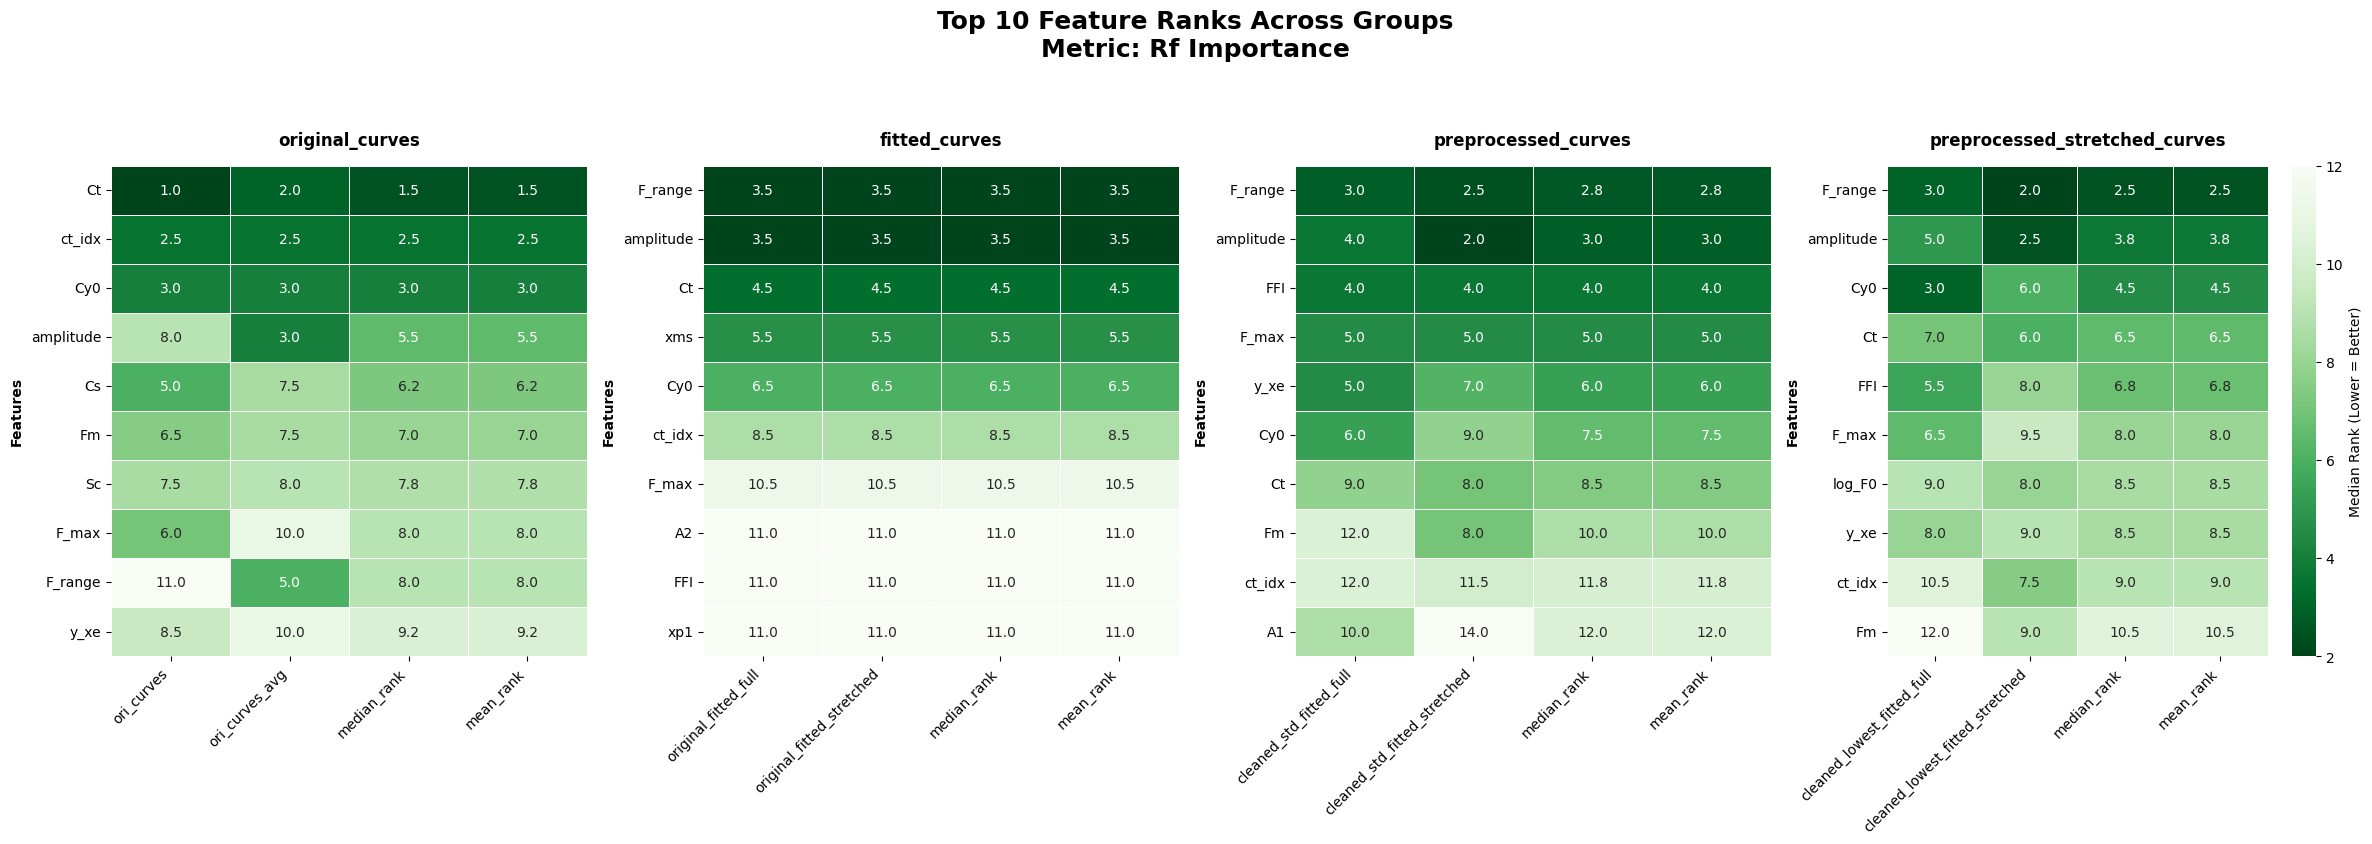

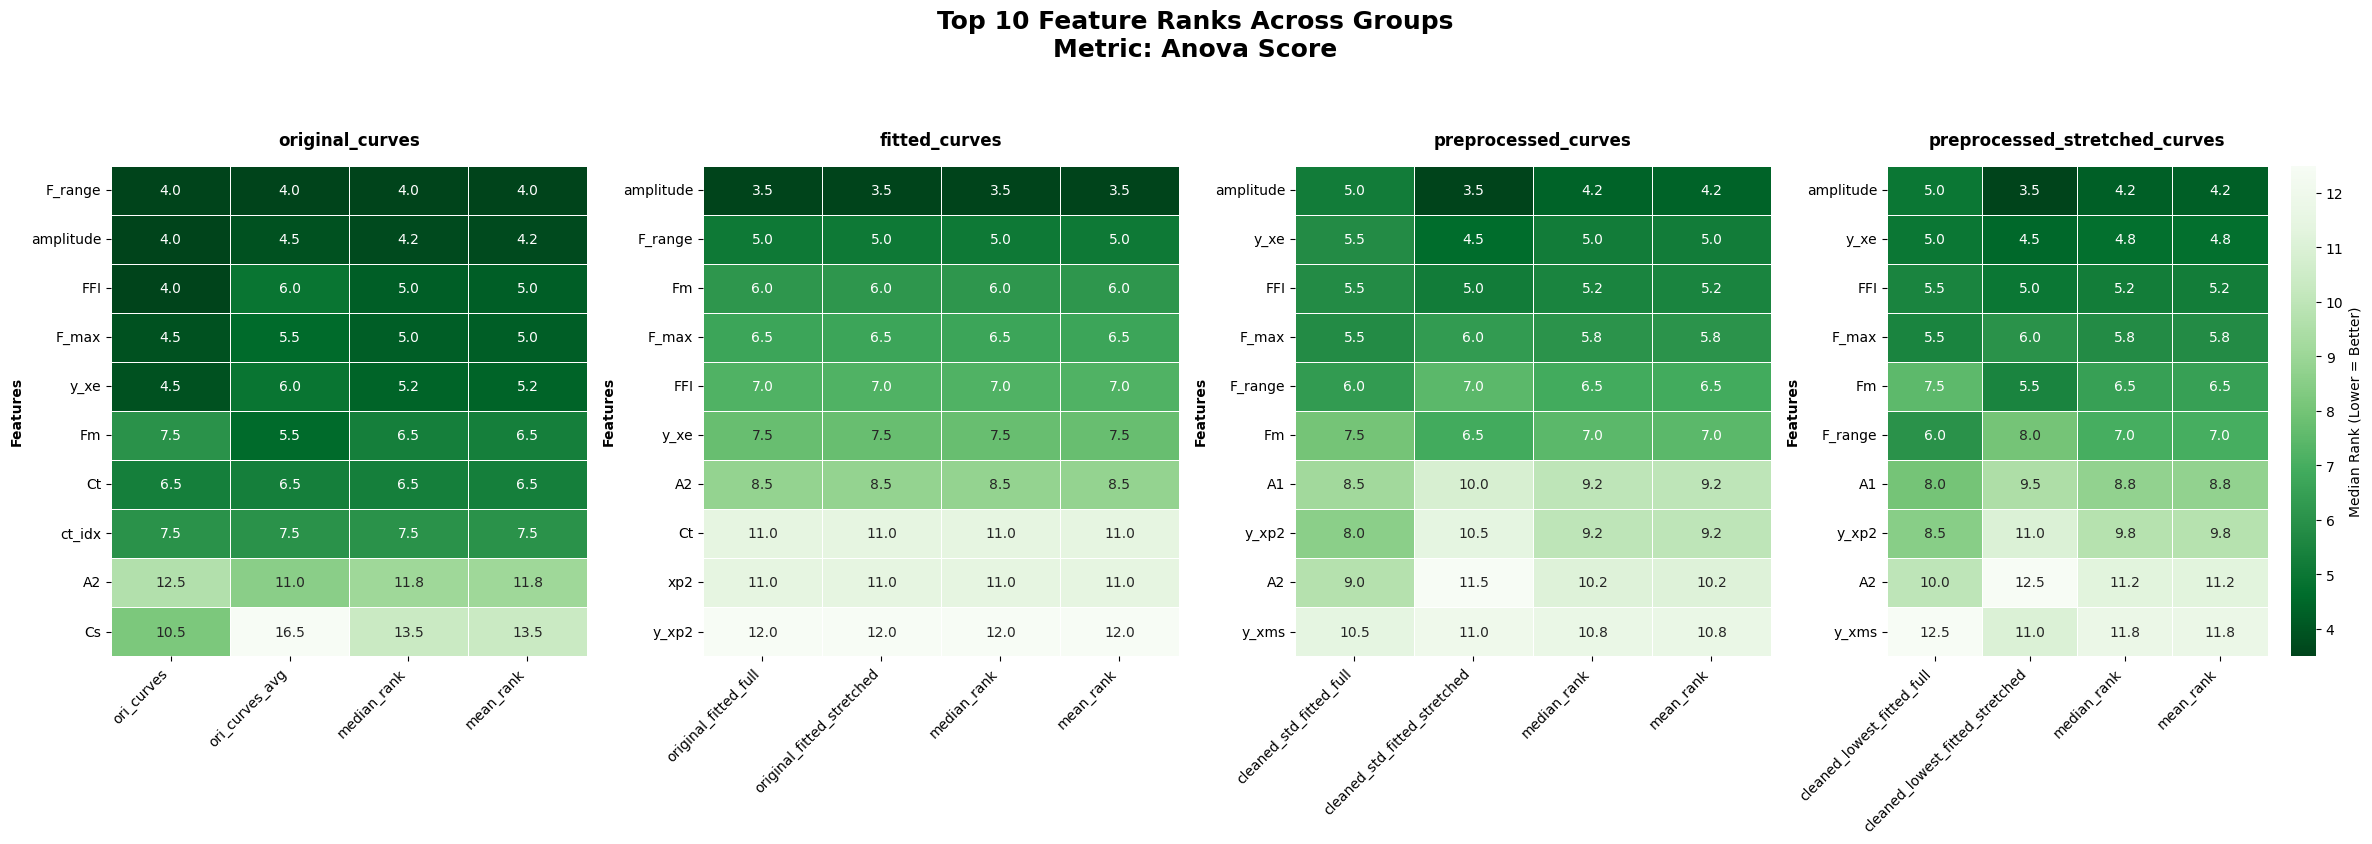

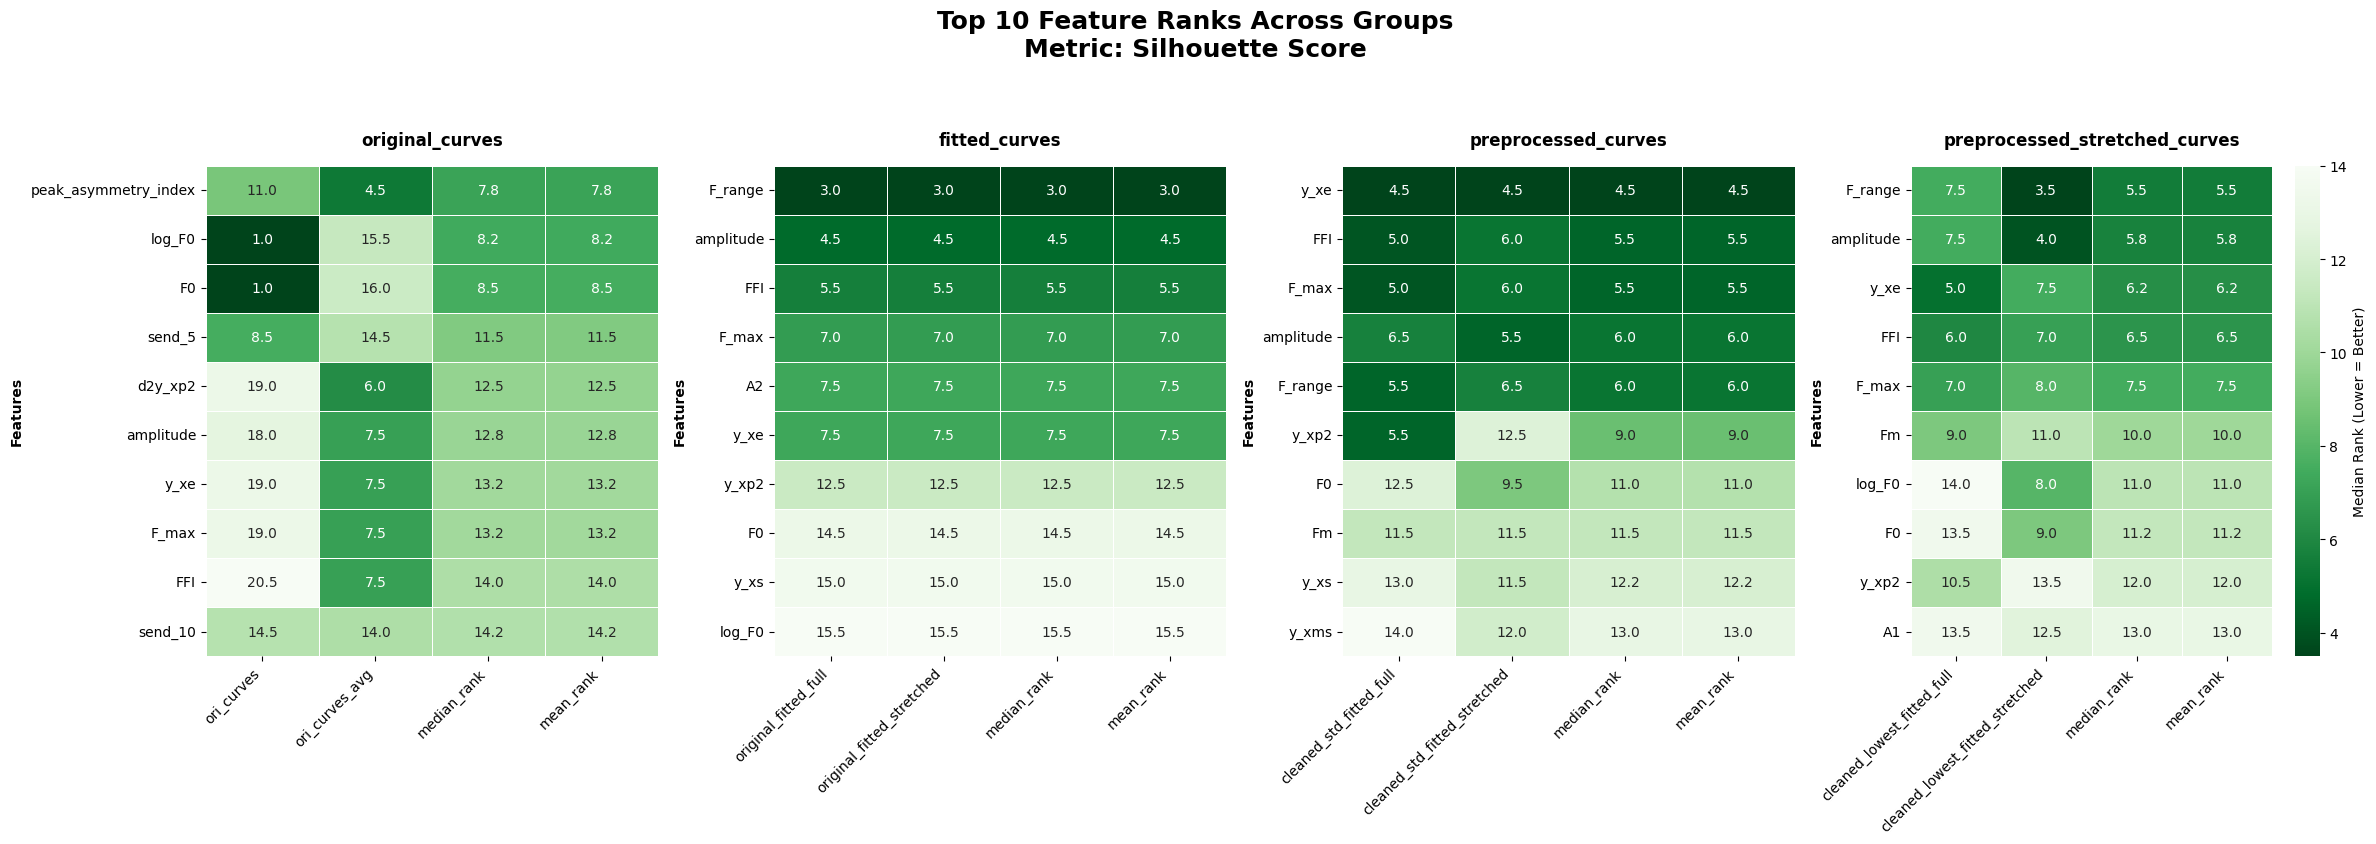

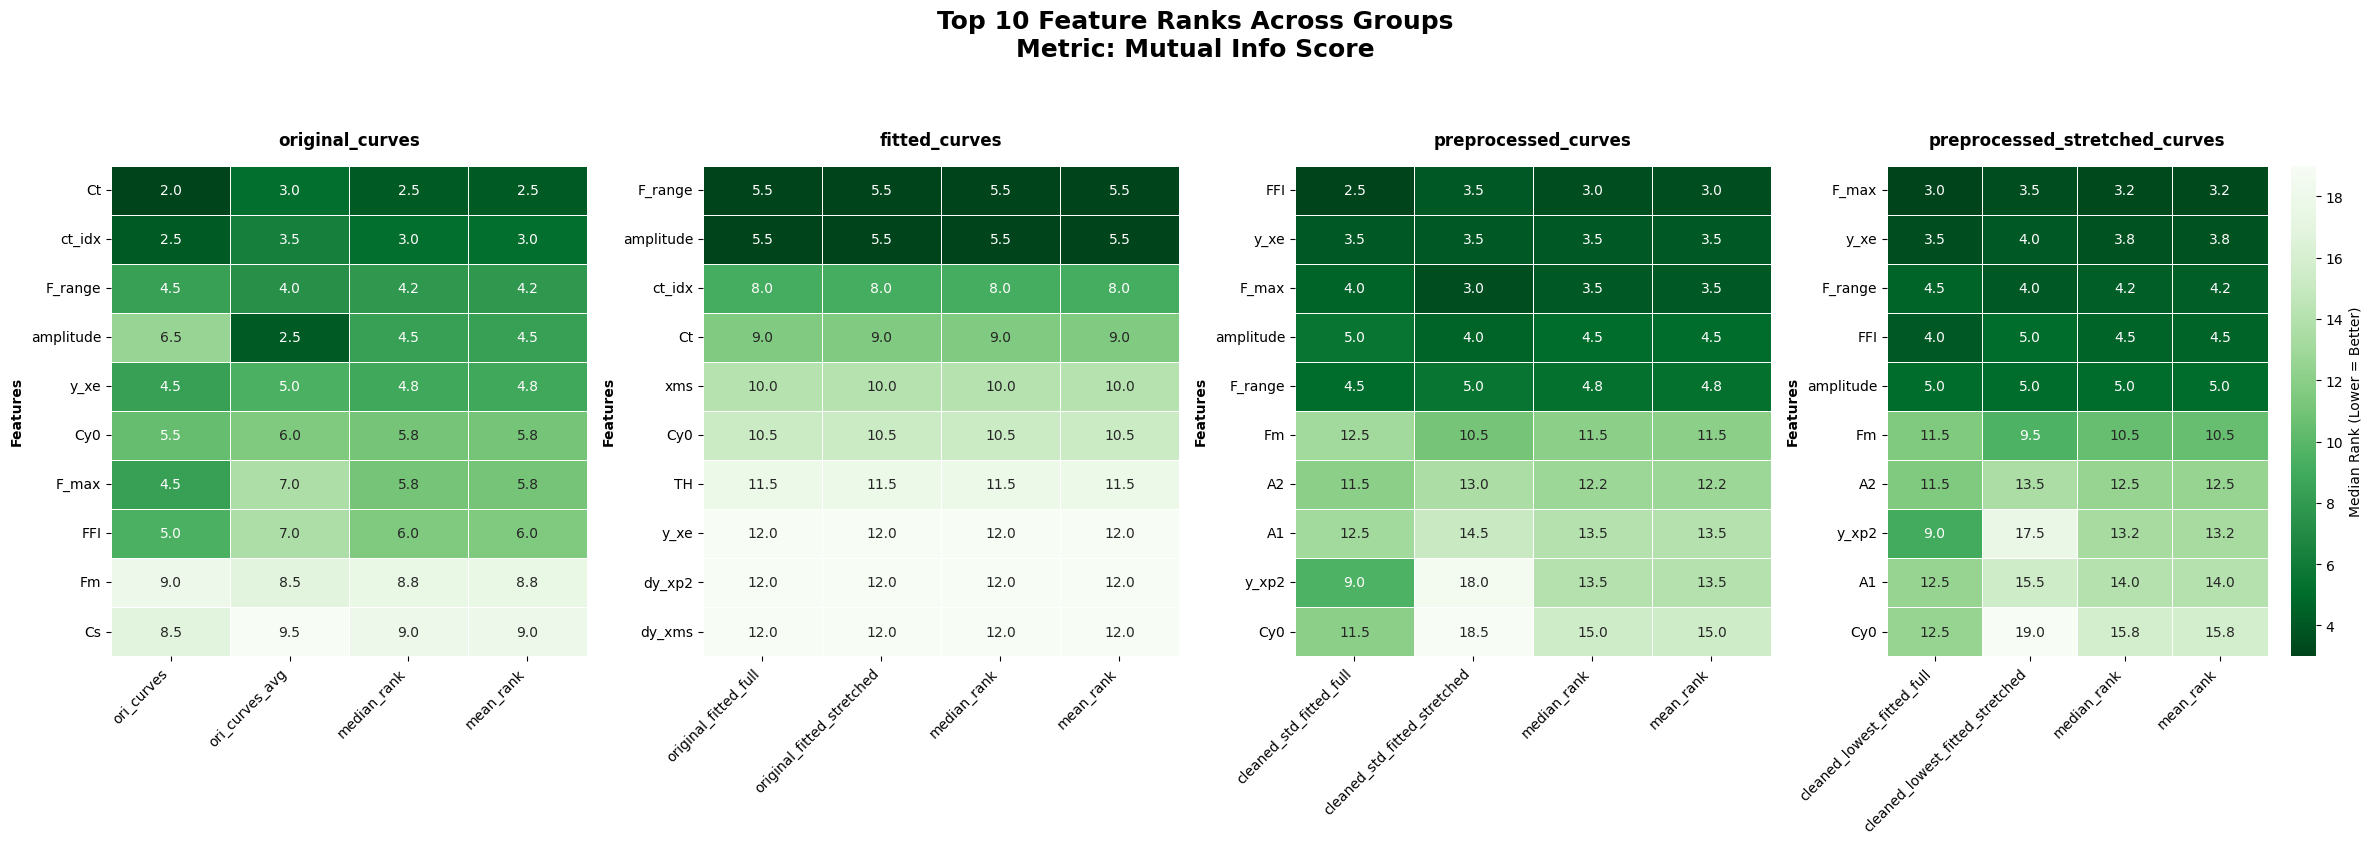

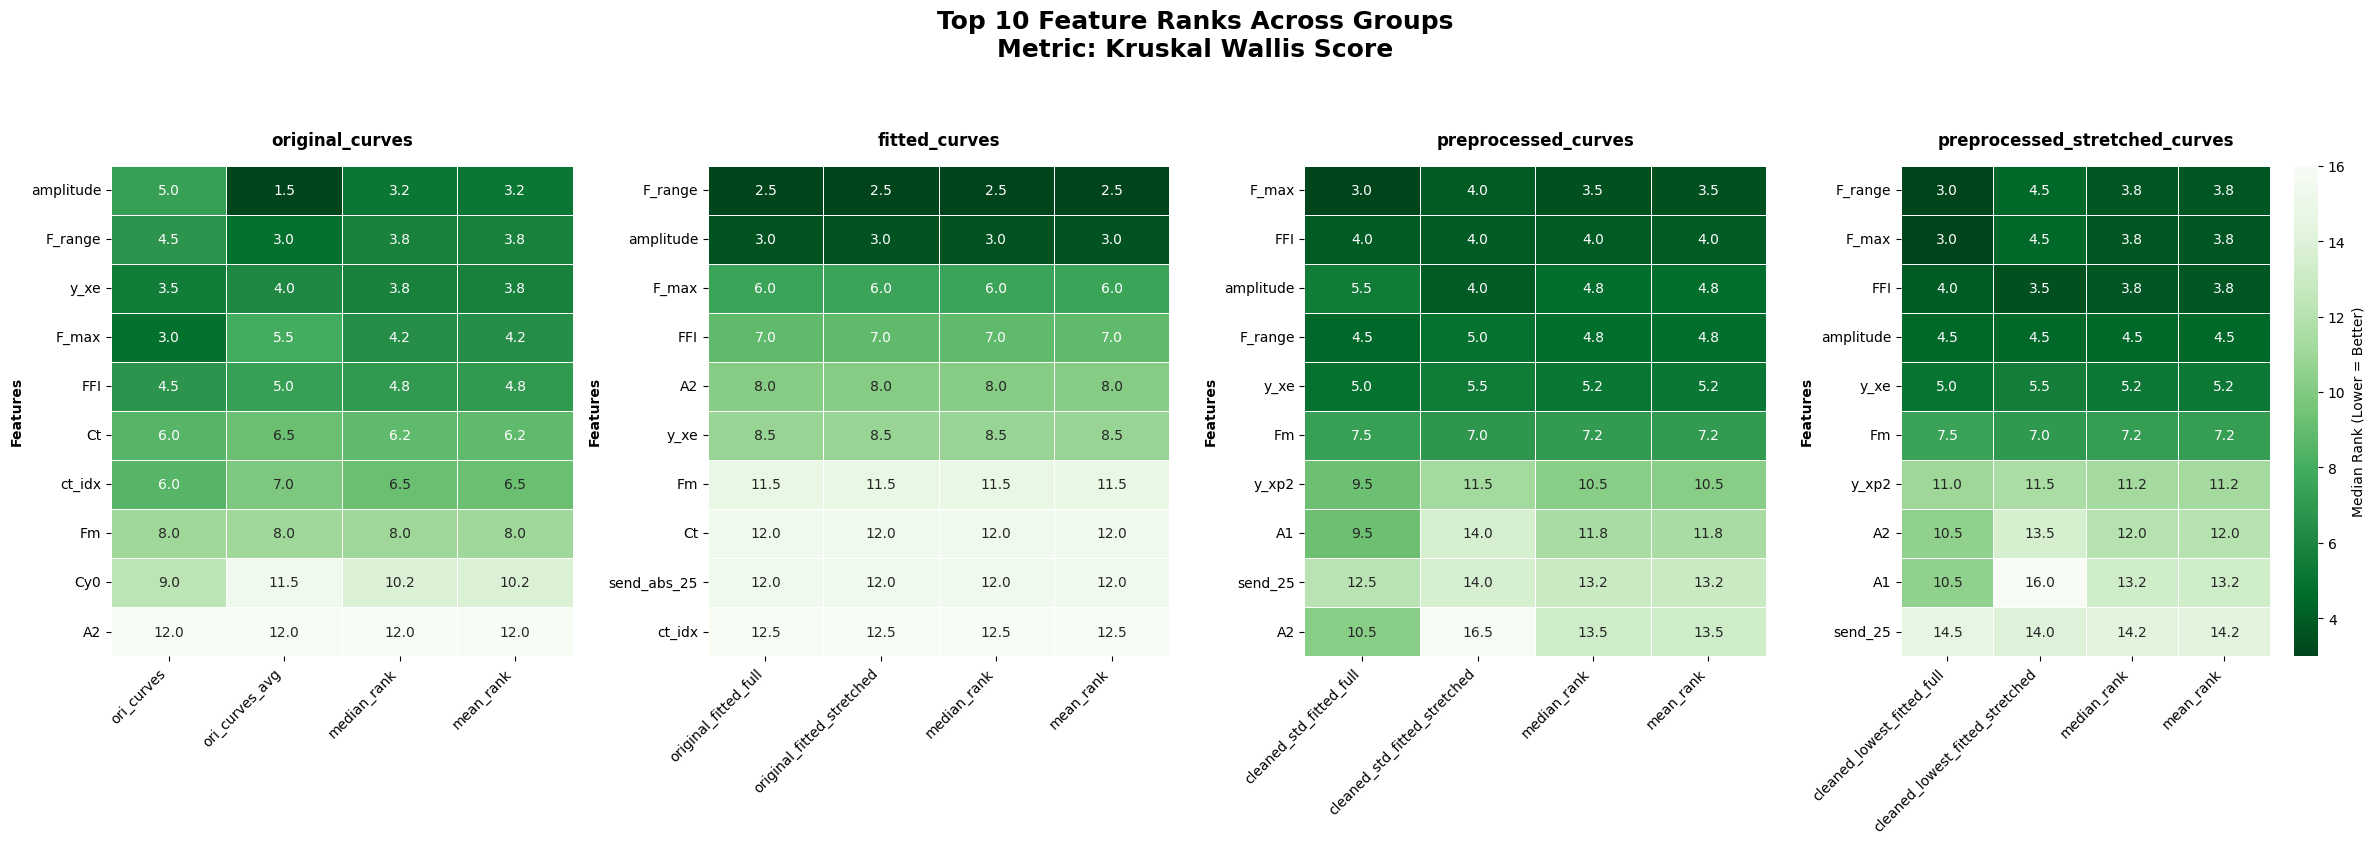

In [16]:
n_splits = len(curve_split)

for m in metrics:
    if m not in summary['curve_feature_median_rank']:
        print(f"Skipping {m} - not found in summary.")
        continue
        
    metric_df = summary['curve_feature_median_rank'][m]
    
    fig, axes = plt.subplots(nrows=1, ncols=n_splits, figsize=(6 * n_splits, 8))
    
    if n_splits == 1:
        axes = [axes]
        
    clean_metric_name = m.replace('_', ' ').title()
    fig.suptitle(f"Top 10 Feature Ranks Across Groups\nMetric: {clean_metric_name}", fontsize=18, fontweight='bold', y=1.05)
    
    for i, (k, v) in enumerate(curve_split.items()):
        split_columns = ['feature'] + v
        
        valid_cols = [c for c in split_columns if c in metric_df.columns]
        
        display_colorbar = (i == n_splits - 1)
        
        plot_feature_heatmap_on_ax(
            df=metric_df[valid_cols], 
            ax=axes[i], 
            title=f"{k}", 
            calculate_summary=True, 
            n_rank=10,
            show_cbar=display_colorbar
        )
        
    plt.tight_layout()
    plt.show()
    
    # Optional: Save the figure dynamically based on the metric name
    # save_path = f"feature_rank_heatmap_{m}.png"
    # plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    
    plt.close(fig)

## Top Features Viz

In [17]:
def plot_feature_visuals(ax_dist, ax_scat, feature, feature_values, y_target, title_text):
    """
    Plots the normalized KDE distribution and the sorted scatter plot for a given feature.
    Automatically handles NaNs and infinite values.
    """
    # Clean Data (NaN / Inf Handling)
    valid_mask = ~np.isnan(feature_values) & ~np.isinf(feature_values)
    val_x = feature_values[valid_mask]
    val_y = y_target[valid_mask]
    
    if len(val_x) == 0:
        ax_dist.set_title(f"{title_text}\n(NO VALID DATA)")
        ax_scat.set_title(f"{title_text}\n(NO VALID DATA)")
        return
        
    df_plot = pd.DataFrame({feature: val_x, 'Target': val_y})
    
    # ---------------------------------------------------------
    # PLOT A: Histogram + KDE Distribution
    # ---------------------------------------------------------
    try:
        # Attempt to plot with KDE
        sns.histplot(
            data=df_plot, x=feature, hue='Target', bins=150, 
            kde=True, stat='density', palette='colorblind', 
            ax=ax_dist, linewidth=0, alpha=0.9, legend=True
        )
        
        # Force the KDE line to be black
        for line in ax_dist.lines:
            line.set_color('black')
            line.set_linewidth(1.5)
            
    except Exception:
        # Fallback if KDE fails due to LinAlgError (Zero Variance / Singular Matrix)
        sns.histplot(
            data=df_plot, x=feature, hue='Target', bins=150, 
            kde=False, stat='density', palette='colorblind', 
            ax=ax_dist, linewidth=0, alpha=0.9, legend=True
        )
        # Add a small note that KDE failed for transparency
        ax_dist.text(0.95, 0.95, 'KDE Failed', transform=ax_dist.transAxes, 
                     color='red', fontsize=8, ha='right', va='top')
        
    ax_dist.set_title(f"{title_text}", fontweight='bold', fontsize=11)
    ax_dist.set_xlabel(feature, fontsize=9)
    ax_dist.set_ylabel("Density", fontsize=9)
    
    # ---------------------------------------------------------
    # PLOT B: Sorted Scatter Plot (Event Number)
    # ---------------------------------------------------------
    sort_indices = np.argsort(val_y)
    sorted_y = val_y[sort_indices]
    sorted_feature = val_x[sort_indices]
    x_events = np.arange(len(sorted_feature))
    
    df_scatter = pd.DataFrame({
        'Event Number': x_events,
        feature: sorted_feature,
        'Target': sorted_y
    })
    
    sns.scatterplot(
        data=df_scatter, x='Event Number', y=feature, hue='Target', 
        palette='colorblind', edgecolor=None, s=25, 
        ax=ax_scat, legend=False
    )

    ax_scat.set_title(f"{title_text}", fontweight='bold', fontsize=11)
    ax_scat.set_xlabel("Event Number", fontsize=9)
    ax_scat.set_ylabel(f"{feature} Intensity", fontsize=9)

In [18]:
SELECTED_DATASET_NAME = "D20250820_E00_C00_F4500KHz_U_Sample_18_wet_3"
SELECTED_CURVE_TYPE = "ori_curves"

dataset_idx = dataset_metadata["name"].index(SELECTED_DATASET_NAME)
curve_idx = curve_metadata["name"].index(SELECTED_CURVE_TYPE)

# 1. Get raw features and pre-calculated scores for this dataset/curve
selected_kf = dataset["kinetic_features"][dataset_idx][curve_idx]
selected_scores = dataset["feature_scores"][dataset_idx][curve_idx]
selected_y_well = np.array(dataset_metadata["Y_well"][dataset_idx])

top_n_ = 10

metrics = [
    "rf_importance", 
    "anova_score", 
    "silhouette_score", 
    "mutual_info_score", 
    "kruskal_wallis_score"
]

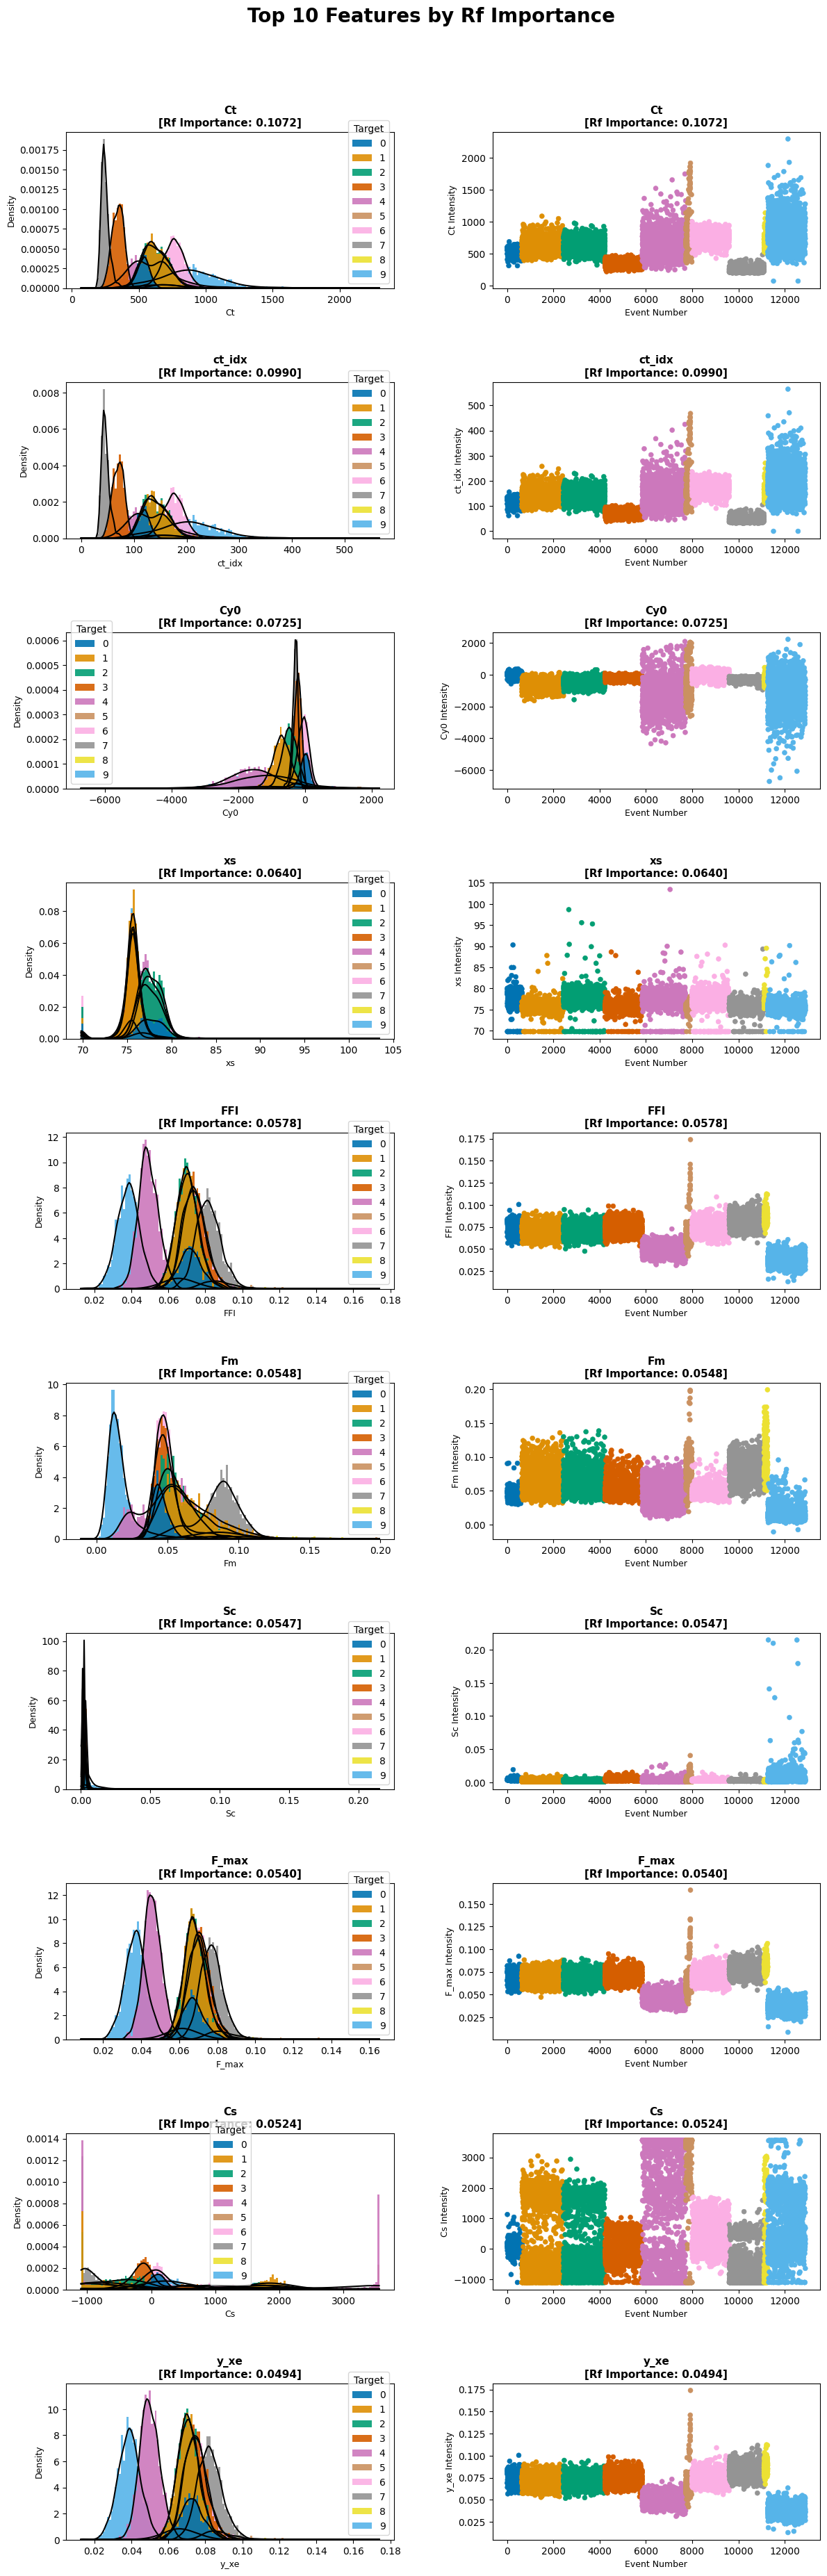

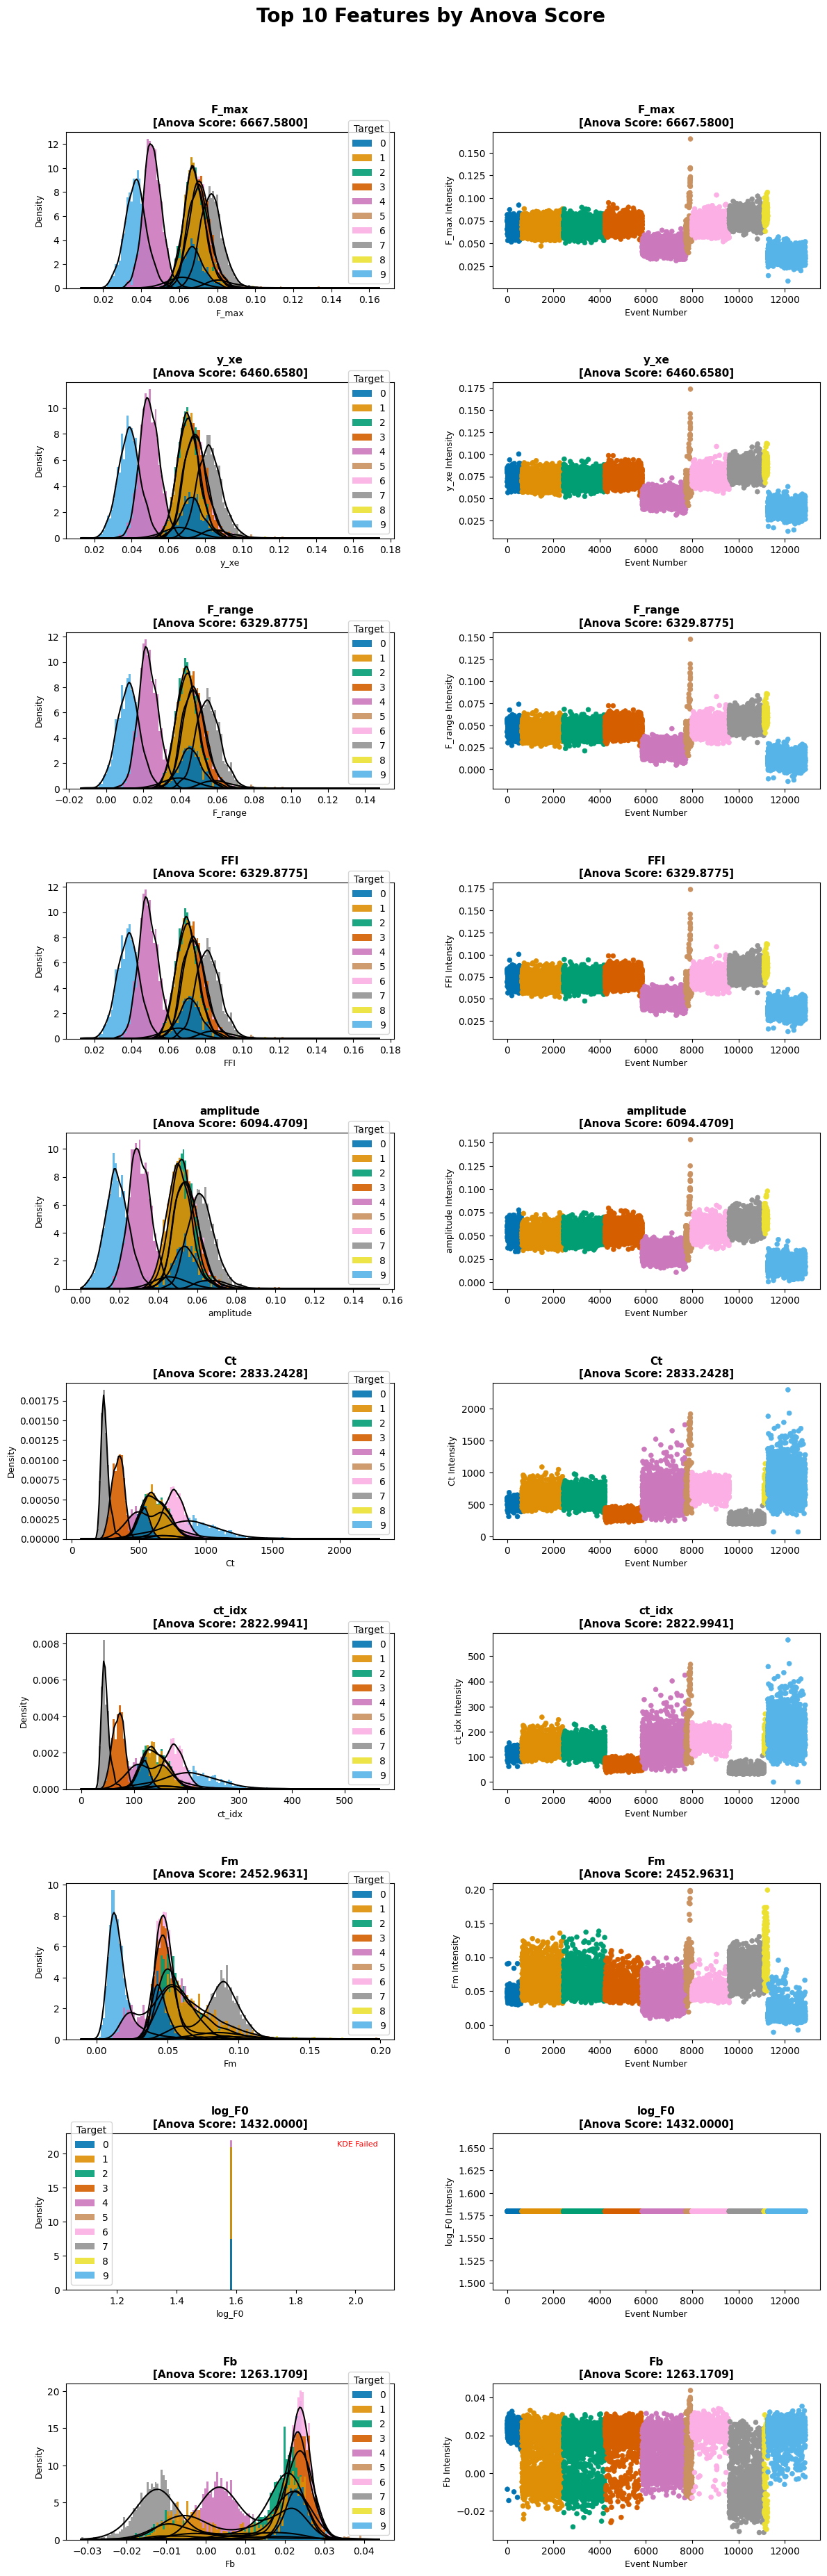

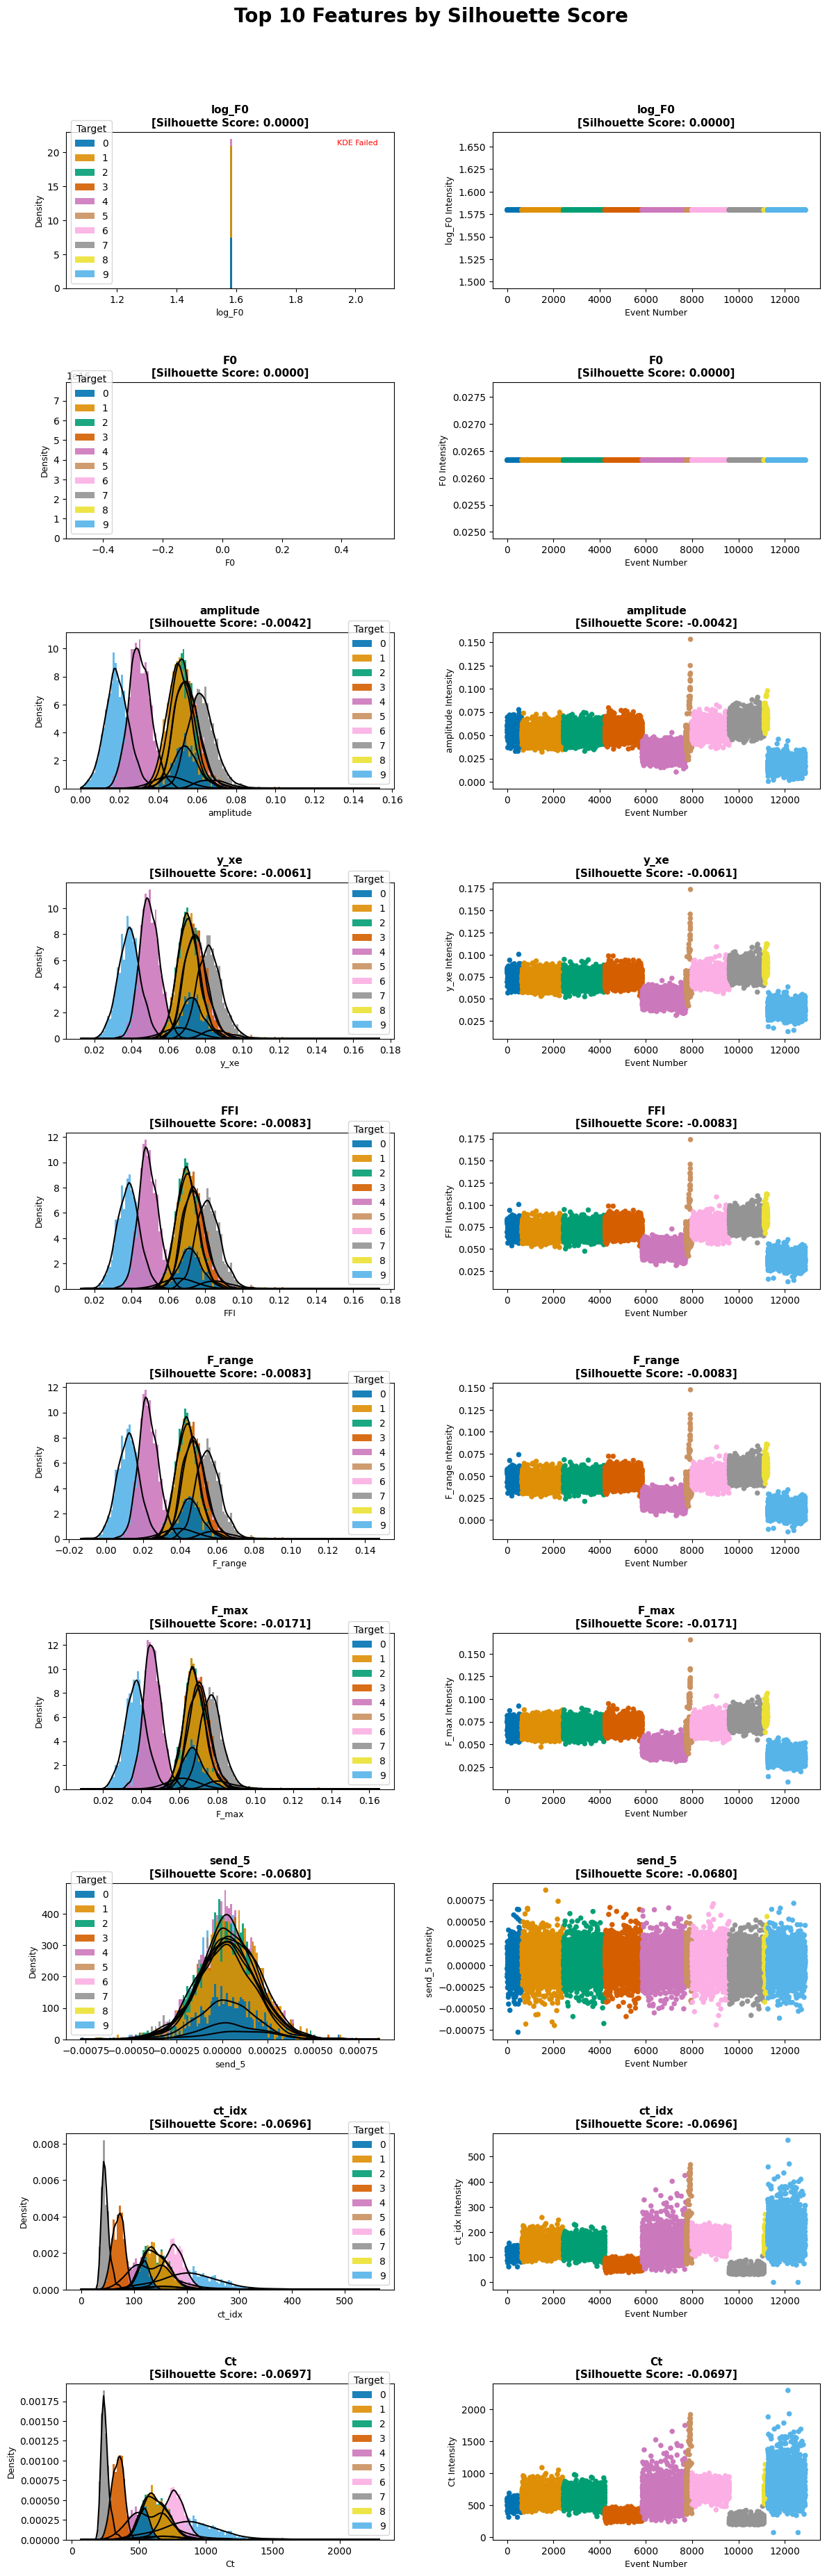

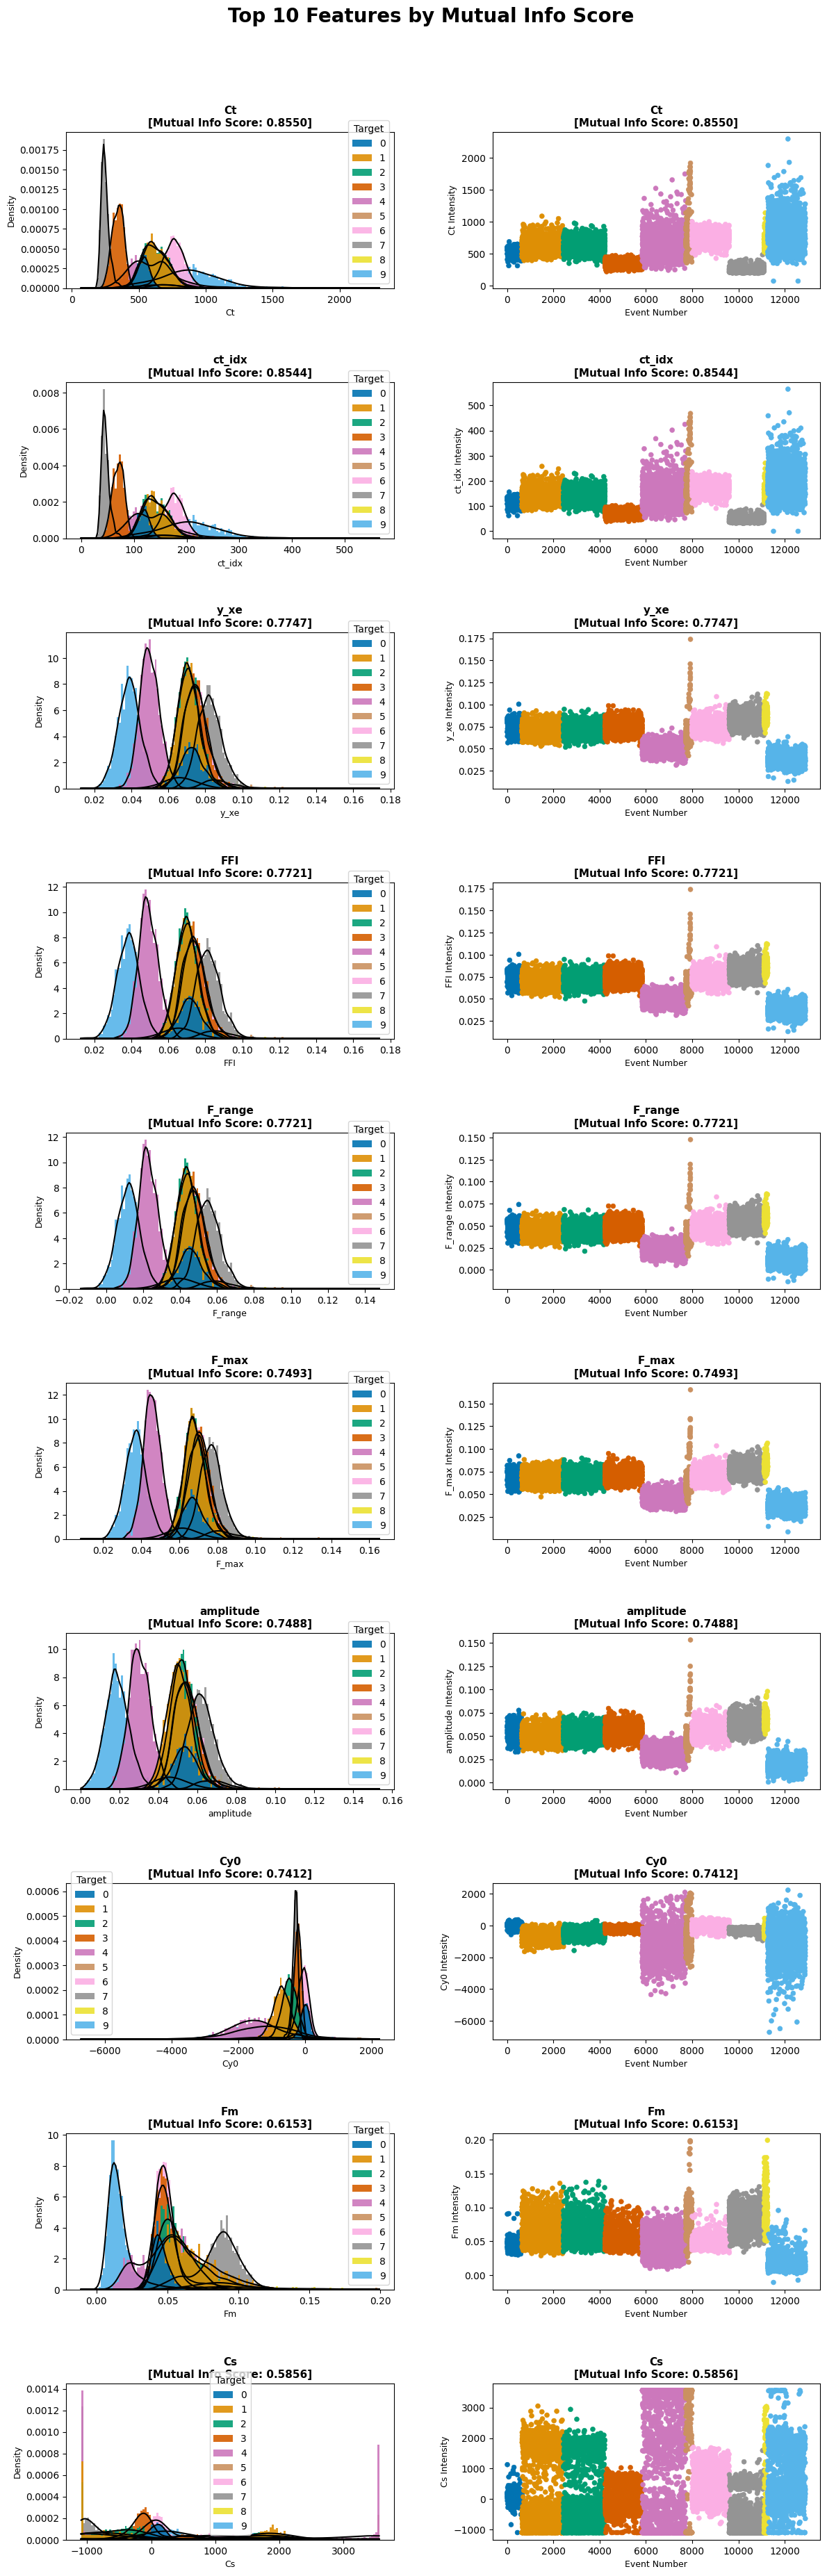

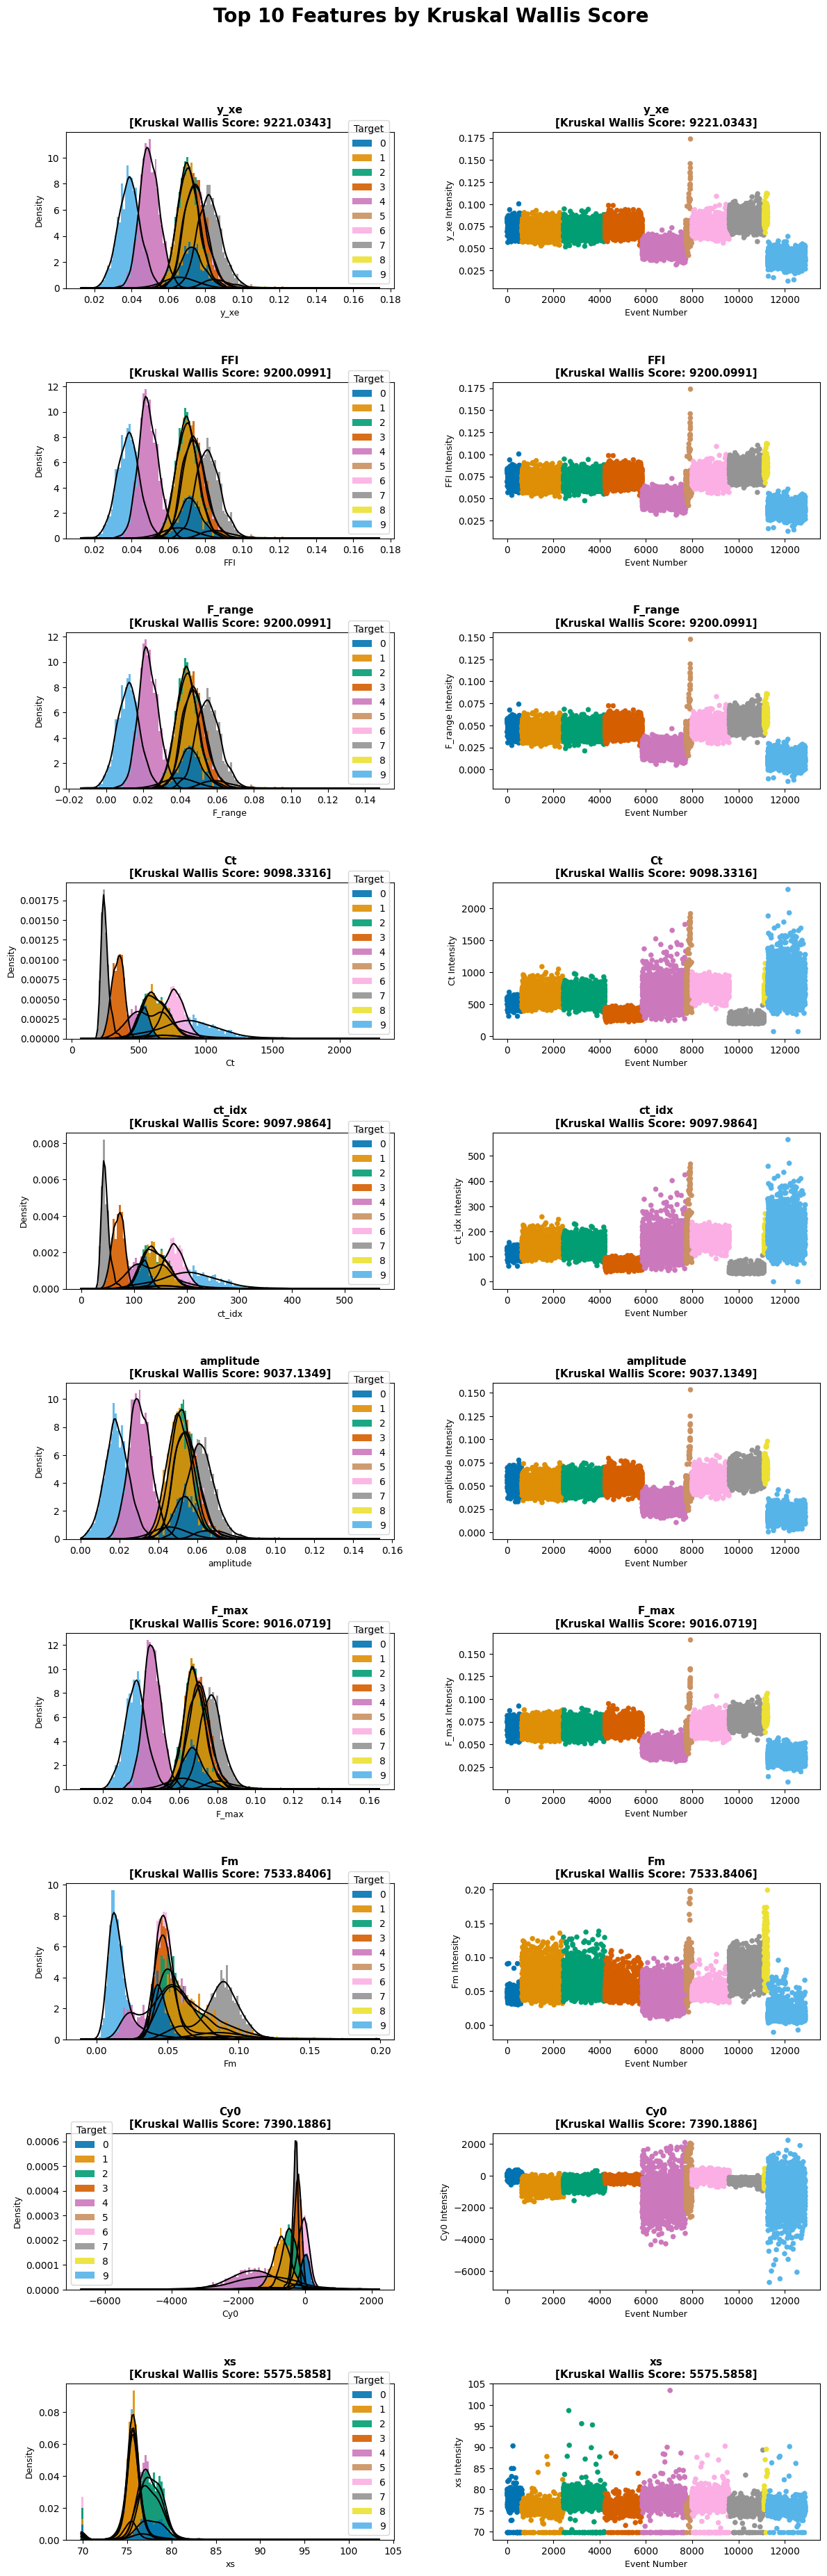

403

In [ ]:
for m in metrics:
    sorted_scores = selected_scores.sort_values(by=m, ascending=False)
    
    valid_scores = sorted_scores[
        sorted_scores['feature'].isin(selected_kf.columns) & 
        ~sorted_scores['feature'].isin(EXCLUDED_FEATURES) &
        ~sorted_scores['feature'].str.contains('label') &
        ~sorted_scores['feature'].str.startswith('knn_top_')
    ].reset_index(drop=True)
    
    top_n_df = valid_scores.head(top_n_)
    
    fig, axes = plt.subplots(top_n_, 2, figsize=(14, top_n_ * 4.5))
    plt.subplots_adjust(hspace=0.6, wspace=0.3) 
    
    clean_metric_name = m.replace('_', ' ').title()
    
    for i in range(len(top_n_df)):
        feat = top_n_df.loc[i, 'feature']
        score_val = top_n_df.loc[i, m]
        feat_vals = selected_kf[feat].values
        
        title = f"{feat}\n[{clean_metric_name}: {score_val:.4f}]"
        
        ax_dist = axes[i, 0] if top_n_ > 1 else axes[0]
        ax_scat = axes[i, 1] if top_n_ > 1 else axes[1]
        
        plot_feature_visuals(ax_dist, ax_scat, feat, feat_vals, selected_y_well, title)
    
    fig.suptitle(f'Top {top_n_} Features by {clean_metric_name}', fontsize=20, fontweight='bold', y=0.92)

    plt.show()
    plt.close(fig)

gc.collect()